09 · Accessibility: what you can reach, and what is there

From here, in fifteen minutes, where can I get and what is there when I
arrive? Notebook 17 answers that through city2graph
(`add_metapaths_by_weight`, `create_isochrone`). This one uses the OSMnx
operators: `osmnx_isochrones`, `osmnx_ego_subgraph`, `osmnx_network_dbscan`,
the six feature operators and `osmnx_snap_pois`. Section 6 puts the two side
by side on the same place, speed and threshold.

Four things, in the order they have to be settled: the cost, the polygon (a
reachable node set is not an area, and that conversion holds most of the
error here), the places, and network distance against distance in the plane.

Network: almost nothing. Every graph and POI set below comes from the cache
notebooks 17, 06 and 07 warmed. Section 4 makes one small Overpass request
(`amenity=restaurant` over 600 m) and falls back to the cached set if the
server refuses.

## 0 · Setup

In [1]:
import pathlib
import sys


def find_repo():
    """Locate the SciGraphs repository, without relying on the cwd.

    In a normal Jupyter the kernel starts per notebook with the cwd set to its
    folder. Not here: the kernel lives inside Blender and existed before you
    opened anything, so the cwd is wherever Blender was launched from. What the
    extension does know is which folder it is serving to JupyterLab.
    """
    candidates = []
    try:
        import bpy
        prefs = bpy.context.preferences.addons[
            "bl_ext.user_default.jupyter_blender"].preferences
        candidates.append(pathlib.Path(bpy.path.abspath(prefs.notebook_dir)))
    except Exception:
        pass
    candidates.append(pathlib.Path.cwd())

    for base in candidates:
        for directory in (base, *base.parents):
            if (directory / "SciGraphs" / "api" / "graphs.py").is_file():
                return directory

    raise RuntimeError(
        "Cannot find the SciGraphs repository. Point at it by hand:\n"
        "    sys.path.insert(0, '/path/to/SciGraphs-1/notebooks/tools')")


sys.path.insert(0, str(find_repo() / "notebooks" / "tools"))

import importlib
import math
import time

import bpy
import numpy as np
import pandas as pd

# `nb` must import first: it puts this repository on sys.path, so the
# `SciGraphs` import below reads this tree, not the copy Blender installed.
import nb
from nb import check

from SciGraphs import api as sg

# Before a single byte moves: the add-on sets `use_cache` but not
# `cache_folder`, so the relative default follows Blender's launch directory
# and a run from two places keeps two caches, neither hit twice (notebook 06).
ox = nb.osmnx()

import city2graph as c2g
import geopandas as gpd
import networkx as nx
import pyproj
from shapely.geometry import LineString, Polygon
from shapely.ops import transform, unary_union

print(f"osmnx  {ox.__version__}")
print(f"cache  {nb.rel(ox.settings.cache_folder)}")

osmnx  2.0.7
cache  notebooks/data/cache/osmnx


### The study area, and the modules that go with it

Ciutat Vella, València, at 600 m: the same center, radius and `walk` filter
notebook 17 uses, because section 6 compares the two answers. 4.8 km/h is the
pedestrian speed the accessibility literature and notebook 17 both assume;
900 s is the fifteen minutes.

The operators run inside the copy of SciGraphs that Blender registered, and
the graphs they hand back live in a module-level dict inside that copy.
`import SciGraphs` reaches a different module object with an empty
cache, so every lookup would come back `None` (notebook 11 works the trap
through). Hence the imports below.

In [2]:
CENTER = (39.4699, -0.3763)      # Ciutat Vella, València
RADIUS_M = 600
SPEED_KPH = 4.8
SPEED_MS = SPEED_KPH * 1000.0 / 3600.0
THRESHOLD_S = 900
METRIC_CRS = "EPSG:25830"        # ETRS89 / UTM 30N
RENDERS = "09_osmnx_accessibility"

INSTALLED = next(k for k in bpy.context.preferences.addons.keys()
                 if k.rsplit(".", 1)[-1].lower() == "scigraphs")
graph_cache = importlib.import_module(INSTALLED + ".core.osmnx.graph_cache")
# `scigraphs_core` is a wheel: one copy in site-packages, shared by the notebook
# and the operators, so the installed/working-tree split does not apply to it.
mesh_bridge = importlib.import_module("scigraphs_core.osmnx.mesh_bridge")
sg_importer = importlib.import_module(INSTALLED + ".core.data_io.importer")
sg_geometry = importlib.import_module(INSTALLED + ".core.mesh.geometry")
sg_geo_mesh = importlib.import_module(INSTALLED + ".core.mesh.geo_mesh")
sg_access = importlib.import_module("scigraphs_core.osmnx.accessibility")
sg_metadata = importlib.import_module("scigraphs_core.osmnx.metadata")

to_utm = pyproj.Transformer.from_crs("EPSG:4326", METRIC_CRS, always_xy=True)
GEOD = pyproj.Geod(ellps="WGS84")

props = bpy.context.scene.scigraphs
sg.graphs.clear_scene(keep_anchor=False)
print("add-on package:", INSTALLED)

add-on package: bl_ext.user_default.scigraphs


### Five helpers

`materialize(G, name)` builds a Blender object from a NetworkX graph with no
download, so the object, the operators and section 6's comparison all look at
the identical cached `MultiDiGraph`. The isochrone and ego highlights below
are induced subgraphs materialized the same way, so they carry real street
geometry. It needs a context override because `create_osmnx_graph_object`
links the new object
through `bpy.context.collection` (`SciGraphs/core/mesh/geometry.py:1740`),
which is `None` under `blender -b`, and that is how `verify_notebooks.py` runs
this file.

`node_attribute(obj, values, name)` puts a per-node quantity on the mesh. An
OSMnx mesh has many more vertices than nodes (`retain_geometry` stores every
shape point of every centerline) and
`mesh_bridge.transfer_node_attribute_to_mesh` leaves all of them at `0.0`, a
value no intersection has, at the bottom of the color ramp. Here each shape
vertex takes the mean of the two intersections its street runs between.
`fill='endpoint'` is the variant for a quantity that does not vary along a
street, a cluster label; section 5 explains it.

`plain(obj)` strips a previous coloring. `sg.render.material()` will not
replace an existing `*_SciGraphsColor` material and rewires whichever color
layer it finds, both deliberately: a graph colored and then rendered has to
keep its colormap. This notebook draws the same network under four
attributes, the one sequence where that is wrong.

`luminance`/`overlay` are notebook 04's arrangement; section 2 explains why a
reachable set needs it.

In [3]:
NODE_FRACTION = 0.16      # the context's node radius; section "Rendering"
CONTEXT = (0.085, 0.080, 0.100)
FAT = 4.0
LAYERS = []               # every graph object, for hide bookkeeping


def materialize(G, name, scale=0.001):
    """A Blender object for a NetworkX graph, with no download."""
    data, geoms = sg_importer.osmnx_to_graph_data(G, retain_geometry=True)
    if data is None:
        return None
    with bpy.context.temp_override(collection=bpy.context.scene.collection,
                                   scene=bpy.context.scene,
                                   view_layer=bpy.context.view_layer):
        obj = sg_geometry.create_osmnx_graph_object(data, geoms, scale=scale,
                                                    retain_geometry=True)
    if obj is None:
        return None
    obj.name = name
    graph_cache.store_osmnx_graph(obj, G)
    obj["osmnx_scale"] = scale
    LAYERS.append(obj)
    return obj


def node_attribute(obj, values, name, fill="mean", default=None):
    """Write a per-node quantity onto an OSMnx mesh, filling the shape points.

    `values` maps node id -> number. `fill='mean'` gives a shape vertex the
    mean of the two intersections its street connects; `fill='endpoint'` gives
    it the shared value when both agree and `default` when they do not.
    """
    mesh = obj.data
    ids = str(obj.get("nodes_data", "")).split(",")
    array = np.zeros(len(mesh.vertices), dtype=np.float64)
    known = np.zeros(len(mesh.vertices), dtype=bool)
    touched = np.zeros(len(mesh.vertices), dtype=bool)

    def key(text):
        return int(text) if text.lstrip("-").isdigit() else text

    for index, node_id in enumerate(ids):
        if index >= len(array):
            break
        value = values.get(key(node_id))
        if value is not None:
            array[index] = float(value)
            known[index] = touched[index] = True

    edge_verts = np.empty(len(mesh.edges) * 2, dtype=np.int32)
    mesh.edges.foreach_get("vertices", edge_verts)
    edge_verts = edge_verts.reshape(-1, 2)
    for (u, v), indices in mesh_bridge.build_edge_mapping(obj).items():
        a, b = values.get(key(u)), values.get(key(v))
        if a is None or b is None:
            continue
        if fill == "mean":
            filler = 0.5 * (float(a) + float(b))
        else:
            filler = float(a) if float(a) == float(b) else float(default)
        for edge_index in indices:
            for vertex in edge_verts[edge_index]:
                if not touched[vertex]:
                    array[vertex] = filler
                    touched[vertex] = True

    real = array[known]
    if len(real) and not touched.all():
        array[~touched] = float(real.mean()) if fill == "mean" else float(default)

    if name in mesh.attributes:
        mesh.attributes.remove(mesh.attributes[name])
    layer = mesh.attributes.new(name=name, type='FLOAT', domain='POINT')
    layer.data.foreach_set("value", array.astype(np.float32).tolist())
    return int(known.sum()), array


def plain(obj):
    """Strip a previous coloring so a flat `color=` decides the object again."""
    layers = obj.data.color_attributes
    for name in [a.name for a in layers]:
        layers.remove(layers[name])
    for key in ("scigraphs_last_color_attribute", "scigraphs_color_attr"):
        if key in obj.keys():
            del obj[key]
    obj.data.materials.clear()
    return obj


def luminance(path):
    """(rgb, luminance) for a PNG, on the 0-255 scale it was written in."""
    from PIL import Image
    rgb = np.asarray(Image.open(str(path)).convert("RGB"), dtype=np.float32)
    return rgb, 0.2126 * rgb[..., 0] + 0.7152 * rgb[..., 1] + 0.0722 * rgb[..., 2]


def overlay(base, highlight, attribute, filename, extra=(),
            node_fraction=NODE_FRACTION, fat=FAT, clip_high_pct=None):
    """Draw `highlight` over `base`, and measure whether it reads.

    Returns the render's path and the two luminances that decide the figure:
    the median of the pixels the highlight reaches (found by rendering the same
                                                    frame again with it hidden) and the median of the context's own ink.
    """
    sizes = sg.render.autoscale_geometry(base, node_fraction=node_fraction,
                                         verbose=False)
    for obj, ratio, color in [(highlight, fat, CONTEXT), *extra]:
        sg.render.autoscale_geometry(obj, node_fraction=node_fraction,
                                     verbose=False)
        obj["scigraphs_node_size"] = sizes["node_radius"] * 0.02
        obj["scigraphs_edge_thickness"] = sizes["edge_radius"] * ratio
        sg.render.material(obj, color=color)
        sg.render.geometry_nodes(obj)
    # `nodes_only` defaults True for a point attribute. These spheres were
    # just shrunk to nothing, so the colormap has to reach the tubes.
    sg.render.color_graph(highlight, attribute, colormap="turbo",
                          nodes_only=False, clip_high_pct=clip_high_pct,
                          verbose=False)

    shown = {base, highlight, *(o for o, _, _ in extra)}
    hidden = [o for o in LAYERS if o not in shown]

    plain(base)
    # `shrink_png` picks its palette per image, so a pair compared pixel by
    # pixel stays unquantized until after the measurement.
    full = nb.render(
        base, filename, look='ink', isolate=False, color=CONTEXT,
        node_fraction=node_fraction, hide=hidden, verbose=False, shrink=False)
    reference = nb.render(
        base, filename + "_context", look='ink', isolate=False, color=CONTEXT,
        node_fraction=node_fraction, hide=hidden + [highlight], verbose=False,
        shrink=False)
    rgb_full, lum_full = luminance(full)
    rgb_ref, lum_ref = luminance(reference)
    reached = np.abs(lum_full - lum_ref) > 8
    ink_ref = np.abs(rgb_ref - rgb_ref.reshape(-1, 3)[0]).sum(axis=2) > 24
    numbers = {
        "highlight_median": float(np.median(lum_full[reached])),
        "highlight_p05": float(np.percentile(lum_full[reached], 5)),
        "highlight_area": float(reached.mean()),
        "context_median": float(np.median(lum_ref[ink_ref])),
    }
    numbers["separation"] = numbers["highlight_median"] - numbers["context_median"]
    plain(base)
    sg.preview.shrink_png(full)
    sg.preview.shrink_png(reference)
    return full, numbers


def report(numbers, label_a, label_b):
    print(f"  {label_a:<26} median luminance "
          f"{numbers['highlight_median']:.0f}, dimmest 5% at "
          f"{numbers['highlight_p05']:.0f}, {numbers['highlight_area']*100:.1f}% "
          f"of the frame")
    print(f"  {label_b:<26} median luminance {numbers['context_median']:.0f}")
    print(f"  {'separation':<26} {numbers['separation']:+.0f} levels")

### The network

`graph_from_point` with the literal coordinates above is a cache hit: it is
the query notebook 17 makes. The operator route would not be, because
`props.osmnx_latitude` is single precision, so `39.4699` goes over the wire as
`39.46989822387695` and keys a second cache entry (notebook 06 derives it).
One more reason this notebook materializes rather than imports.

In [4]:
t0 = time.time()
G = ox.graph_from_point(CENTER, dist=RADIUS_M, network_type="walk",
                        simplify=True)
print(f"{time.time() - t0:.1f} s")
print(f"walk network: {G.number_of_nodes()} intersections, "
      f"{G.number_of_edges()} directed segments, crs {G.graph.get('crs')}")
print("edge attributes:", sorted(next(iter(G.edges(data=True)))[2].keys()))

obj_net = materialize(G, "Walk_CiutatVella")
print(sg.graphs.summary(obj_net))

# `sg.preview.extent()` reads `obj["node_positions"]`, which
# `create_osmnx_graph_mesh` never writes
# (`SciGraphs/core/mesh/geometry.py:1750`), so it falls back to all mesh
# vertices and measures centerline sampling instead of junction spacing: node
# radii come out about 3.8x too small. `sg.render.node_cloud()` reads the
# `is_intersection` layer that importer does write.
cloud, cloud_source = sg.render.node_cloud(obj_net)
(_c, _s, _d, median_nn), _src = sg.render.measure(obj_net)
print(f"mesh {len(obj_net.data.vertices)} vertices, node cloud {len(cloud)} "
      f"via '{cloud_source}', median nearest neighbor {median_nn * 1000:.1f} m")
check("the node cloud is the junctions, not the street shape points",
      cloud_source == "is_intersection" and len(cloud) == obj_net["num_nodes"])

1.5 s
walk network: 1472 intersections, 4396 directed segments, crs epsg:4326
edge attributes: ['highway', 'length', 'oneway', 'osmid', 'reversed']

Creating OSMnx graph: 1,472 nodes, 4,396 edges...
  Created 1,472 intersection vertices
    Created 1,000 edges...
    Created 2,000 edges...
  Created 2,178 street edges in 0.29s
Total OSMnx graph creation time: 0.29s
{'object': 'Walk_CiutatVella', 'type': 'MESH', 'num_nodes': 1472, 'num_edges': 4396, 'is_directed': True, 'vertices': 3444, 'mesh_edges': 4150, 'attributes': ['is_intersection', 'position', '.edge_verts', '.corner_vert', '.corner_edge']}
mesh 3444 vertices, node cloud 1472 via 'is_intersection', median nearest neighbor 7.6 m
[PASS] the node cloud is the junctions, not the street shape points


True

## 1 · What `osmnx_isochrones` computes, and on what cost

Notebook 17 records that `c2g_graph_tool_apply` with `ISOCHRONE` rebuilds the
graph from the Blender mesh, whose edges carry no attribute, so NetworkX falls
back to weight 1 and the threshold counts hops while the panel calls it a
distance. `SCIGRAPHS_OT_OSMnxIsochrones` never looks at the mesh: it pulls the
`MultiDiGraph` out of the importer's cache (`accessibility_operators.py:88`)
and hands it to `make_iso_polygons`, which runs
`single_source_dijkstra_path_length` with a weight function
(`SciGraphs/core/osmnx/accessibility.py:96-117`) reading `travel_time` off
each edge and, where there is none, deriving one from `length` at the panel's
speed. `length` is the great-circle length OSMnx computed at download time, in
meters, so the threshold really is minutes. The one place in the suite where
the OSMnx operator is more faithful than the city2graph one.

In [5]:
def edge_travel_time(_u, _v, data):
    """`_edge_weight` from `accessibility.py:96`, rewritten to be readable.

    NetworkX hands a MultiDiGraph's parallel edges in as a dict of dicts; the
    cheapest of them wins.
    """
    if data and all(isinstance(value, dict) for value in data.values()):
        candidates = list(data.values())
    else:
        candidates = [data]
    best = math.inf
    for edge in candidates:
        seconds = edge.get("travel_time")
        if seconds is None:
            seconds = (edge.get("length", 0.0) or 0.0) / SPEED_MS
        best = min(best, seconds)
    return best


lengths = np.array([d["length"] for *_e, d in G.edges(data=True)])
print(f"segment length: median {np.median(lengths):.1f} m, "
      f"total {lengths.sum() / 1000:.2f} km")
print(f"at {SPEED_KPH} km/h that is {np.median(lengths) / SPEED_MS:.1f} s "
      f"for the median segment")
check("no edge carries a travel_time yet",
      not any("travel_time" in d for *_e, d in G.edges(data=True)),
      "so the operator is about to impute all of them")

segment length: median 20.9 m, total 127.53 km
at 4.8 km/h that is 15.6 s for the median segment
[PASS] no edge carries a travel_time yet — so the operator is about to impute all of them


True

### The speed is written once and never again

Before the Dijkstra the operator calls `add_travel_time_from_speed`
(`accessibility_operators.py:103`), which writes `travel_time` onto every edge
of the cached graph, guarded by
`if "travel_time" not in data or data["travel_time"] is None`
(`accessibility.py:27`): the docstring says it does not overwrite existing
values.

The consequence is not in the docstring. After the first run every edge has a
`travel_time`, so a second run at a different speed imputes zero edges and
returns the same isochrone; `make_iso_polygons` takes `travel_speed_kph` too
and uses it only for edges still missing one. Change the speed, press the
button, and the picture does not move. Nothing reports it.

In [6]:
added = sg_access.add_travel_time_from_speed(G, SPEED_KPH)
times = np.array([d["travel_time"] for *_e, d in G.edges(data=True)])
print(f"imputed travel_time on {added} of {G.number_of_edges()} edges")
print(f"implied speed: {np.median(lengths / times):.4f} m/s "
      f"(asked for {SPEED_MS:.4f})")

again = sg_access.add_travel_time_from_speed(G, 15.0)
times_after = np.array([d["travel_time"] for *_e, d in G.edges(data=True)])
print(f"a second call at 15 km/h imputed {again} edges and changed "
      f"{int((times_after != times).sum())} of {len(times)}")
check("the imputed speed is sticky: the second call is a no-op",
      again == 0 and not (times_after != times).any(),
      "the panel's speed field does nothing after the first run")

imputed travel_time on 4396 of 4396 edges
implied speed: 1.3333 m/s (asked for 1.3333)
a second call at 15 km/h imputed 0 edges and changed 0 of 4396
[PASS] the imputed speed is sticky: the second call is a no-op — the panel's speed field does nothing after the first run


True

### The distances, and what bounds them

In [7]:
center_node = ox.distance.nearest_nodes(G, X=CENTER[1], Y=CENTER[0])
print(f"center node {center_node}: out-degree {G.out_degree(center_node)}, "
      f"in-degree {G.in_degree(center_node)}")

seconds = nx.single_source_dijkstra_path_length(G, center_node,
                                                weight=edge_travel_time)
reach = np.array(sorted(seconds.values()))
print(f"\nreachable at all: {len(seconds)} of {G.number_of_nodes()}")
for budget in (300, 600, 900):
    n = int((reach <= budget).sum())
    print(f"  <= {budget:4d} s ({budget // 60:2d} min): {n:5d} nodes "
          f"({100 * n / G.number_of_nodes():5.1f}%)")
print(f"\neccentricity from this node: {reach.max():.0f} s "
      f"= {reach.max() * SPEED_MS:.0f} m of network")

center node 5902851069: out-degree 3, in-degree 3

reachable at all: 1472 of 1472
  <=  300 s ( 5 min):   332 nodes ( 22.6%)
  <=  600 s (10 min):  1230 nodes ( 83.6%)
  <=  900 s (15 min):  1472 nodes (100.0%)

eccentricity from this node: 858 s = 1144 m of network


> **A fifteen-minute isochrone on a 600 m download is a picture
> of the download.** At 4.8 km/h a 900 s budget buys 1200 m along the network,
> and the furthest intersection here is 858 s away, so the 15-minute ring
> below contains every node there is and its boundary is the edge of the
> Overpass query. The operator reports three polygons and two of them mean
> what they say.
>
> The download radius has to exceed `speed x threshold`, with slack for
> streets not being straight: 1200 m of network fits inside about 900 m of
> radius, so a 600 m download can honestly answer 10 minutes, not 15.
>
> Notebook 06's GraphML cache key has the same trap from the other side
> (`SciGraphs/core/osmnx/cache.py:78-105` omits the radius): a cache hit can
> hand back a graph downloaded at a different radius, and an isochrone cannot
> tell the difference. Check the node and edge counts against what you asked
> for.

The two thresholds this notebook can defend are 5 and 10 minutes. Section 6
keeps 15 only to compare against notebook 17's answer.

In [8]:
check("15 minutes saturates this download",
      int((reach <= THRESHOLD_S).sum()) == G.number_of_nodes(),
      f"{reach.max():.0f} s eccentricity against a {THRESHOLD_S} s budget")
check("10 minutes does not",
      int((reach <= 600).sum()) < G.number_of_nodes(),
      f"{int((reach <= 600).sum())} of {G.number_of_nodes()} nodes")

[PASS] 15 minutes saturates this download — 858 s eccentricity against a 900 s budget
[PASS] 10 minutes does not — 1230 of 1472 nodes


True

### The first figure

Straight down through an orthographic camera (`render_eevee`'s default, never
overridden in this suite), so this is a plan of Ciutat Vella and can be
measured off the page.

The turbo ramp carries `node_travel_time_s`, the walking seconds from the
center intersection to every other one, as a point attribute. There is no
per-edge color on a graph: a graph mesh has no faces, so
`SciGraphs/core/coloring/attributes.py:227` averages an `EDGE` attribute over
the edges meeting at each vertex, and on a street network only 44 % of tubes
come out constant. `nodes_only=False` lets the tubes take the node values, so
each tube interpolates between two real costs.

node_travel_time_s written on 1472 intersections, 1972 shape vertices interpolated
domain: POINT
  Skipping Split Edges: 'is_intersection' present, keeping streets continuous
Info: Geometry Nodes modifier added
Info: Attribute -> node_travel_time_s  ·  node_travel_time_s -> turbo [log]  [0 … 857.9] on Point


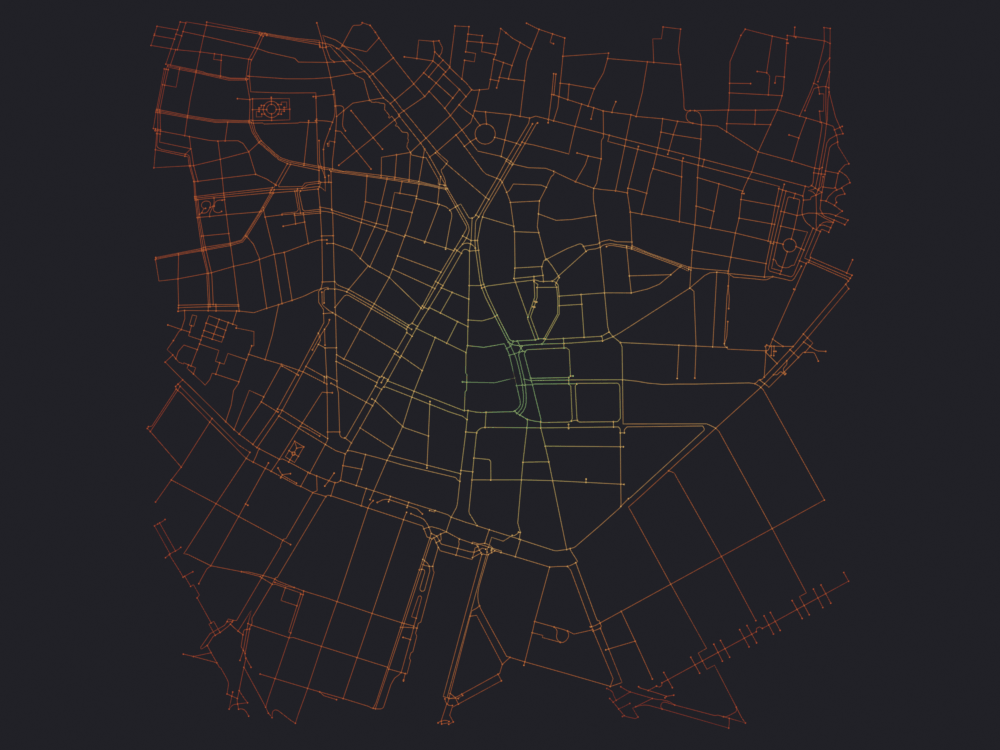

[PASS] 1_travel_time.png legible — 8.4% ink (healthy range 0.5–60%)


In [9]:
written, values = node_attribute(obj_net, seconds, "node_travel_time_s")
print(f"node_travel_time_s written on {written} intersections, "
      f"{len(obj_net.data.vertices) - written} shape vertices interpolated")
print("domain:", sg.render.attribute_domain(obj_net, "node_travel_time_s"))

nb.figure(obj_net, f"renders/{RENDERS}/1_travel_time",
          look='ink', color_attribute="node_travel_time_s",
          nodes_only=False, node_fraction=NODE_FRACTION)

## 2 · From a set of nodes to a polygon

The Dijkstra is the honest half. Turning the reachable nodes into an area is
the other, and `make_iso_polygons` offers two ways; both have arithmetic in
them that is wrong.

- `CONVEX_HULL` takes the convex hull of the reachable nodes. Fast, and it
  claims reachability across every concavity in the city: a river bend, a
  walled block, the far side of a barrier.
- `BUFFER_UNION` buffers each reachable node and edge by `buffer_m` and unions
  the result. Much closer to the truth, and the default.

In [10]:
polygons = {}
for mode in ("CONVEX_HULL", "BUFFER_UNION"):
    rings = sg_access.make_iso_polygons(G, center_node, [5, 10, 15],
                                        travel_speed_kph=SPEED_KPH, mode=mode,
                                        buffer_m=25.0)
    for entry in rings:
        polygons[(mode, entry["time"])] = entry["polygon"]

print(f"{'minutes':>8}  {'convex hull':>12}  {'buffer union':>13}  {'hull is':>9}")
for minutes in (5, 10, 15):
    hull = transform(to_utm.transform, polygons[("CONVEX_HULL", minutes)]).area
    buf = transform(to_utm.transform, polygons[("BUFFER_UNION", minutes)]).area
    print(f"{minutes:>8}  {hull / 1e6:>11.4f} km2  {buf / 1e6:>12.4f} km2  "
          f"{100 * (hull - buf) / buf:>8.1f}%")

 minutes   convex hull   buffer union    hull is
       5       0.3096 km2        0.2980 km2       3.9%
      10       1.1800 km2        1.0206 km2      15.6%
      15       1.3712 km2        1.1861 km2      15.6%


### The holes the operator fills in

A buffer union over a street network is full of holes: every city block the
buffer does not reach is an interior ring, the parts of the area you cannot
walk on. The operator throws them away, building each mesh from
`p.exterior.coords` alone (`accessibility_operators.py:154-159`), so the drawn
isochrone is the outer boundary with every courtyard filled solid.

In [11]:
for minutes in (5, 10, 15):
    poly = transform(to_utm.transform, polygons[("BUFFER_UNION", minutes)])
    parts = list(getattr(poly, "geoms", [poly]))
    holes = sum(len(part.interiors) for part in parts)
    exterior = unary_union([Polygon(part.exterior) for part in parts])
    print(f"  {minutes:2d} min: {holes:3d} interior rings, "
          f"{poly.area / 1e6:.4f} km2 true against "
          f"{exterior.area / 1e6:.4f} km2 drawn "
          f"(+{100 * (exterior.area - poly.area) / poly.area:.1f}%)")

check("the buffer union really is full of holes",
      sum(len(p.interiors) for p in [transform(to_utm.transform,
      polygons[("BUFFER_UNION", 15)])]) > 50,
      "and the operator draws only the outer ring of each")

   5 min:  28 interior rings, 0.2980 km2 true against 0.3136 km2 drawn (+5.2%)
  10 min:  87 interior rings, 1.0206 km2 true against 1.1242 km2 drawn (+10.2%)
  15 min: 105 interior rings, 1.1861 km2 true against 1.3167 km2 drawn (+11.0%)
[PASS] the buffer union really is full of holes — and the operator draws only the outer ring of each


True

### `buffer_m` is not meters, and on a projected graph it is
nothing at all

`accessibility.py:154` and `:163` both buffer by `buffer_m / 111000.0`, with
the comment `# deg approx`: 111 km is roughly one degree of latitude. But
shapely buffers isotropically in whatever units the geometry is in, and one
degree of longitude is 111 km only at the equator. At this latitude the same
number of degrees is a fifth shorter east to west, so the buffer is an ellipse
and the isochrone is systematically narrower across than it is up.

In [12]:
extent = sg_metadata.get_graph_extent(G)
lat0, lon0 = extent["center_lat"], extent["center_lon"]
degrees = 25.0 / 111000.0
_a, _b, north_south = GEOD.inv(lon0, lat0, lon0, lat0 + degrees)
_a, _b, east_west = GEOD.inv(lon0, lat0, lon0 + degrees, lat0)
print(f"buffer_m = 25 m at latitude {lat0:.4f} becomes "
      f"{north_south:.2f} m north-south and {east_west:.2f} m east-west "
      f"({100 * (1 - east_west / north_south):.1f}% narrower)")

buffer_m = 25 m at latitude 39.4710 becomes 25.01 m north-south and 19.38 m east-west (22.5% narrower)


The same constant makes the default mode unusable on a projected
graph. Nothing stops you projecting first (notebook 07 and
`SciGraphs/core/osmnx/edge_attributes.py:44-51` give reasons to), but
`make_iso_polygons` has no `is_projected` branch. On a graph in meters the
buffer is 0.000225 m, and the union of a few thousand hairlines is not a
polygon of anything.

In [13]:
G_projected = ox.project_graph(G)
projected = sg_access.make_iso_polygons(G_projected, center_node, [10],
                                        travel_speed_kph=SPEED_KPH,
                                        mode="BUFFER_UNION", buffer_m=25.0)
collapsed = projected[0]["polygon"]
print(f"projected graph crs: {G_projected.graph['crs']}")
print(f"BUFFER_UNION on it: {collapsed.geom_type}, area {collapsed.area:.1f} m2")
print(f"the same threshold unprojected: "
      f"{transform(to_utm.transform, polygons[('BUFFER_UNION', 10)]).area:,.0f} m2")
check("BUFFER_UNION collapses on a projected graph",
      collapsed.area < 1000.0,
      "buffer_m / 111000 is 0.000225 in meters")

projected graph crs: EPSG:32630
BUFFER_UNION on it: Polygon, area 23.4 m2
the same threshold unprojected: 1,020,600 m2
[PASS] BUFFER_UNION collapses on a projected graph — buffer_m / 111000 is 0.000225 in meters


True

### The edges it buffers are not the streets

The mildest of the three approximations. `accessibility.py:156-163` draws each
reachable edge as a straight `LineString` between its endpoints, ignoring the
geometry OSMnx keeps for it. On a simplified graph an edge follows the bend of
the street, so a curved street can leave the polygon that is supposed to
contain it. Measured against the real centerlines:

In [14]:
reachable_10 = {n for n, s in seconds.items() if s <= 600}
edges_gdf = ox.graph_to_gdfs(G, nodes=False).to_crs(METRIC_CRS)
inside = edges_gdf[[u in reachable_10 and v in reachable_10
                   for u, v, _k in edges_gdf.index]]
poly_10 = transform(to_utm.transform, polygons[("BUFFER_UNION", 10)])
escaped = inside.geometry.difference(poly_10).length.sum()
print(f"reachable street length at 10 min: {inside.length.sum():,.0f} m")
print(f"falling outside the drawn polygon: {escaped:,.0f} m "
      f"({100 * escaped / inside.length.sum():.1f}%)")

reachable street length at 10 min: 108,908 m
falling outside the drawn polygon: 1,079 m (1.0%)


### The reachable set as geometry, not as a flag

Membership in an isochrone is binary, and both ends of turbo are its darkest
stops, so a 0/1 attribute puts the two halves of the answer at nearly the same
luminance; this suite has produced two near-illegible plates that way.
Notebook 04 moved membership to geometry instead: the subset as a second
object with thicker tubes on the same origin, the context flattened to a
near-neutral, color left to carry a magnitude, here the travel time.

The subset is an induced subgraph through the same importer, so it lands
exactly on top of the whole network. The 10-minute set carries the ramp; the
flat neutral underneath is the whole network, which is the 15-minute set
entire. The outer tier is not a ring because it has run out of city to be a
ring in.


Creating OSMnx graph: 1,230 nodes, 3,708 edges...
  Created 1,230 intersection vertices
    Created 1,000 edges...
  Created 1,839 street edges in 0.20s
Total OSMnx graph creation time: 0.20s
10-minute subgraph: 1230 nodes, 3708 edges
 5-minute subgraph: 332 nodes
15-minute subgraph: 1472 nodes, the whole network
  Skipping Split Edges: 'is_intersection' present, keeping streets continuous
Info: Geometry Nodes modifier added
Info: Attribute -> node_travel_time_s  ·  node_travel_time_s -> turbo [log]  [0 … 599.8] on Point
  Skipping Split Edges: 'is_intersection' present, keeping streets continuous
Info: Geometry Nodes modifier added
  Skipping Split Edges: 'is_intersection' present, keeping streets continuous
Info: Geometry Nodes modifier added


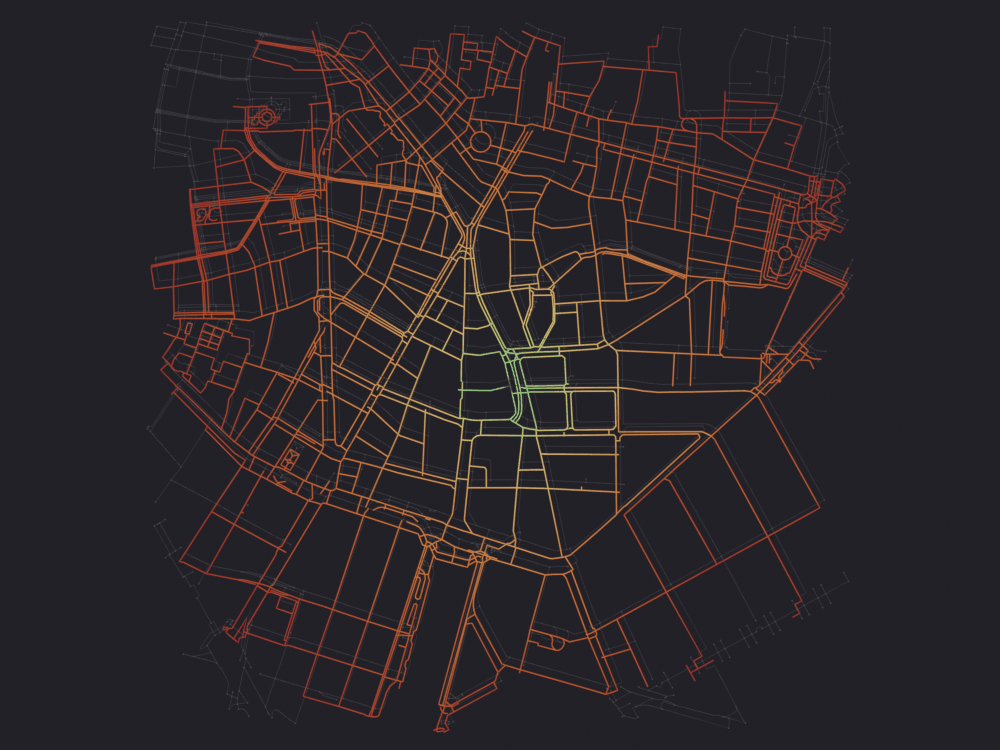

[PASS] 2_isochrone_bands.png legible — 14.0% ink (healthy range 0.5–60%)
  10-minute set              median luminance 78, dimmest 5% at 45, 9.7% of the frame
  network (= 15 minutes)     median luminance 47
  separation                 +32 levels


In [15]:
reachable_5 = {n for n, s in seconds.items() if s <= 300}
obj_10 = materialize(G.subgraph(reachable_10).copy(), "Reach_10min")
node_attribute(obj_10, seconds, "node_travel_time_s")
print(f"10-minute subgraph: {obj_10['num_nodes']} nodes, {obj_10['num_edges']} edges")
print(f" 5-minute subgraph: {len(reachable_5)} nodes")
print(f"15-minute subgraph: {G.number_of_nodes()} nodes, the whole network")

path, numbers = overlay(obj_net, obj_10, "node_travel_time_s",
                        f"renders/{RENDERS}/2_isochrone_bands")
nb.show(path)
nb.check_render(path)
report(numbers, "10-minute set", "network (= 15 minutes)")

## 3 · Ego subgraphs: a hop is not a distance

`osmnx_ego_subgraph` keeps the nodes reachable within a radius of a center.
The dialog labels its field Radius (m) and the operator hardcodes
`distance_attr="length"` (`accessibility_operators.py:221`), so from the
interface the radius is always meters. The function underneath
(`accessibility.py:39-50`) documents `distance_attr=None` for `nx.ego_graph`'s
hop counting, which nothing in the panel can reach.

That is the right default. A hop is one simplified segment, and a simplified
segment is not a unit of anything: on this graph the shortest fifth are under
3 m and the longest is over 300.

### What a hop radius buys, in meters

In [16]:
print("segment length, meters: "
      + "  ".join(f"p{q}={np.percentile(lengths, q):.1f}"
      for q in (5, 50, 95, 100)))
print()
print(f"{'hops':>5}  {'nodes':>6}  {'reach: median':>14}  {'max':>9}")
hop_sets = {}
meters_from_center = nx.single_source_dijkstra_path_length(G, center_node,
                                                           weight="length")
for hops in (4, 8, 12, 16, 24):
    sub = nx.ego_graph(G, center_node, radius=hops)
    hop_sets[hops] = set(sub.nodes)
    spans = [meters_from_center[n] for n in sub.nodes]
    print(f"{hops:>5}  {sub.number_of_nodes():>6}  {np.median(spans):>11.0f} m  "
          f"{max(spans):>7.0f} m")

print(f"\n{'meters':>7}  {'nodes':>6}  {'closest hop radius':>20}  {'nodes':>6}  "
      f"{'Jaccard':>8}")
meter_sets = {}
for meters in (200.0, 300.0, 400.0):
    sub = sg_access.ego_subgraph(G, center_node, meters, distance_attr="length")
    meter_sets[meters] = set(sub.nodes)
    best = min(hop_sets, key=lambda h: abs(len(hop_sets[h]) - len(meter_sets[meters])))
    a, b = meter_sets[meters], hop_sets[best]
    print(f"{meters:>6.0f}   {len(a):>6}  {best:>16} hops  {len(b):>6}  "
          f"{len(a & b) / len(a | b):>8.2f}")

BEST_HOPS = min(hop_sets, key=lambda h: abs(len(hop_sets[h]) - len(meter_sets[300.0])))
overlap = (len(meter_sets[300.0] & hop_sets[BEST_HOPS])
           / len(meter_sets[300.0] | hop_sets[BEST_HOPS]))
check("hops and meters do not select the same nodes", overlap < 0.75,
      f"the closest hop radius by size ({BEST_HOPS}) still disagrees on "
      f"{100 * (1 - overlap):.0f}% of the union")

segment length, meters: p5=2.8  p50=20.9  p95=81.2  p100=321.3

 hops   nodes   reach: median        max
    4      35           72 m      272 m
    8     145          176 m      434 m
   12     361          286 m      878 m
   16     713          410 m     1074 m
   24    1263          553 m     1144 m

 meters   nodes    closest hop radius   nodes   Jaccard
   200       87                 4 hops      35      0.34
   300      198                 8 hops     145      0.61
   400      332                12 hops     361      0.66
[PASS] hops and meters do not select the same nodes — the closest hop radius by size (8) still disagrees on 39% of the union


True

A hop radius grows fastest where the segments are shortest, in
the dense core where a pedestrian crossing is its own node, and stalls along a
long peripheral street, which is backwards from what a catchment means. Hence
the furthest node of a hop-bounded set sitting two to four times as far as its
median one.

### Out is not in

`nx.ego_graph` on a `MultiDiGraph` follows edges forwards, so
`osmnx_ego_subgraph` returns where you can get to from here, not who can reach
you. On a pedestrian network the two coincide, because OSMnx marks every walk
edge two-way; on a drive network they do not, and nothing in the operator, the
panel or the report says which question it answered.

The `drive` network here is also a cache hit, from notebook 07.

In [17]:
Gd = ox.graph_from_point(CENTER, dist=RADIUS_M, network_type="drive",
                         simplify=True)
print(f"drive network: {Gd.number_of_nodes()} nodes, {Gd.number_of_edges()} edges, "
      f"{sum(1 for n in Gd.nodes if Gd.out_degree(n) == 0)} sinks, "
      f"{sum(1 for n in Gd.nodes if Gd.in_degree(n) == 0)} sources")

# The node nearest the center is a sink, so an ego subgraph rooted there is one
# node and no edges, reported as success: `osmnx_ego_subgraph` only rejects an
# empty result (`accessibility_operators.py:222`), the same missing check
# notebook 06 finds in `osmnx_truncate_distance`. Below uses the node with the
# most balanced reach in both directions instead.
naive = ox.distance.nearest_nodes(Gd, X=CENTER[1], Y=CENTER[0])
print(f"nearest node to the center: {naive}, out-degree "
      f"{Gd.out_degree(naive)}, in-degree {Gd.in_degree(naive)}")
print(f"  ego subgraph rooted there, 400 m: "
      f"{sg_access.ego_subgraph(Gd, naive, 400.0).number_of_nodes()} node, "
      f"reported as a result")

reversed_drive = Gd.reverse(copy=False)
usable = max(Gd.nodes, key=lambda n: min(len(nx.descendants(Gd, n)),
             len(nx.descendants(reversed_drive, n))))
print(f"node used below: {usable}, reaches {len(nx.descendants(Gd, usable))}, "
      f"reached by {len(nx.descendants(reversed_drive, usable))}")

print(f"\n{'radius':>7}  {'outbound':>9}  {'inbound':>8}  {'both':>6}  "
      f"{'one way only':>13}")
for meters in (200.0, 400.0, 600.0):
    out = set(nx.ego_graph(Gd, usable, radius=meters, distance="length").nodes)
    into = set(nx.ego_graph(reversed_drive, usable, radius=meters,
               distance="length").nodes)
    print(f"{meters:>6.0f}   {len(out):>9}  {len(into):>8}  {len(out & into):>6}  "
          f"{len(out ^ into):>13}")

out_400 = set(nx.ego_graph(Gd, usable, radius=400.0, distance="length").nodes)
in_400 = set(nx.ego_graph(reversed_drive, usable, radius=400.0,
             distance="length").nodes)
check("the drive ego subgraph is directional",
      len(out_400 ^ in_400) > 0,
      f"{len(out_400 ^ in_400)} nodes are reachable in one direction only")

drive network: 193 nodes, 292 edges, 10 sinks, 16 sources
nearest node to the center: 5902824970, out-degree 0, in-degree 1
  ego subgraph rooted there, 400 m: 1 node, reported as a result
node used below: 25767293, reaches 166, reached by 165

 radius   outbound   inbound    both   one way only
   200           4         3       1              5
   400          14        21       1             33
   600          31        51       5             72
[PASS] the drive ego subgraph is directional — 33 nodes are reachable in one direction only


True

### One more consequence, and it is not local

`osmnx_ego_subgraph` writes the truncated graph back into the importer's cache
(`accessibility_operators.py:226`) and updates the object's node and edge
counts, but does not rebuild the mesh; the Blender object still holds every
street of the original download. Notebook 06 documents the same fault across
`graph_operators.py:477-480, 518-521, 575-578, 663-666, 707-710, 754-757` and
`spatial_operators.py:949-952, 1032-1035`. Here it has a second effect.

Every operator that puts something in the viewport derives the local origin
from `get_graph_extent(G)`, the mean of the graph's node coordinates
(`SciGraphs/core/osmnx/metadata.py:33-34`), while the mesh was built from the
mean of the original node set. Truncate the graph and the two part company, so
an isochrone generated afterwards is drawn from a different origin than the
network it sits on.

In [18]:
truncated = sg_access.ego_subgraph(G, center_node, 300.0, distance_attr="length")
before = sg_metadata.get_graph_extent(G)
after = sg_metadata.get_graph_extent(truncated)
_a, _b, drift = GEOD.inv(before["center_lon"], before["center_lat"],
                         after["center_lon"], after["center_lat"])
print(f"node centroid before: {before['center_lat']:.6f}, {before['center_lon']:.6f}")
print(f"node centroid after : {after['center_lat']:.6f}, {after['center_lon']:.6f}")
print(f"anything drawn from the truncated graph lands {drift:.1f} m off the mesh")
check("truncation moves the origin the viewport geometry is built on",
      drift > 10.0, f"{drift:.1f} m on a 1.2 km frame")

node centroid before: 39.470956, -0.377150
node centroid after : 39.470301, -0.376333
anything drawn from the truncated graph lands 101.1 m off the mesh
[PASS] truncation moves the origin the viewport geometry is built on — 101.1 m on a 1.2 km frame


True

### The figure

Three tiers on the walk network: the whole thing in the flat neutral, the
hop-bounded ego in a mid gray, the 300 m ego carrying the ramp. The two
subsets are as close in size as the hop ladder allows, so anything the figure
shows is a difference in shape, not in how much was kept. The ramp is the
network distance from the center, the quantity a hop radius does not know
about.


Creating OSMnx graph: 198 nodes, 566 edges...
  Created 198 intersection vertices
  Created 282 street edges in 0.01s
Total OSMnx graph creation time: 0.01s

Creating OSMnx graph: 145 nodes, 408 edges...
  Created 145 intersection vertices
  Created 204 street edges in 0.00s
Total OSMnx graph creation time: 0.00s
300 m ego: 198 nodes; 8-hop ego: 145 nodes; in both: 130; in one only: 83
  Skipping Split Edges: 'is_intersection' present, keeping streets continuous
Info: Geometry Nodes modifier added
  Skipping Split Edges: 'is_intersection' present, keeping streets continuous
Info: Geometry Nodes modifier added
Info: Attribute -> node_meters  ·  node_meters -> turbo [log]  [0 … 298.9] on Point
  Skipping Split Edges: 'is_intersection' present, keeping streets continuous
Info: Geometry Nodes modifier added
  Skipping Split Edges: 'is_intersection' present, keeping streets continuous
Info: Geometry Nodes modifier added


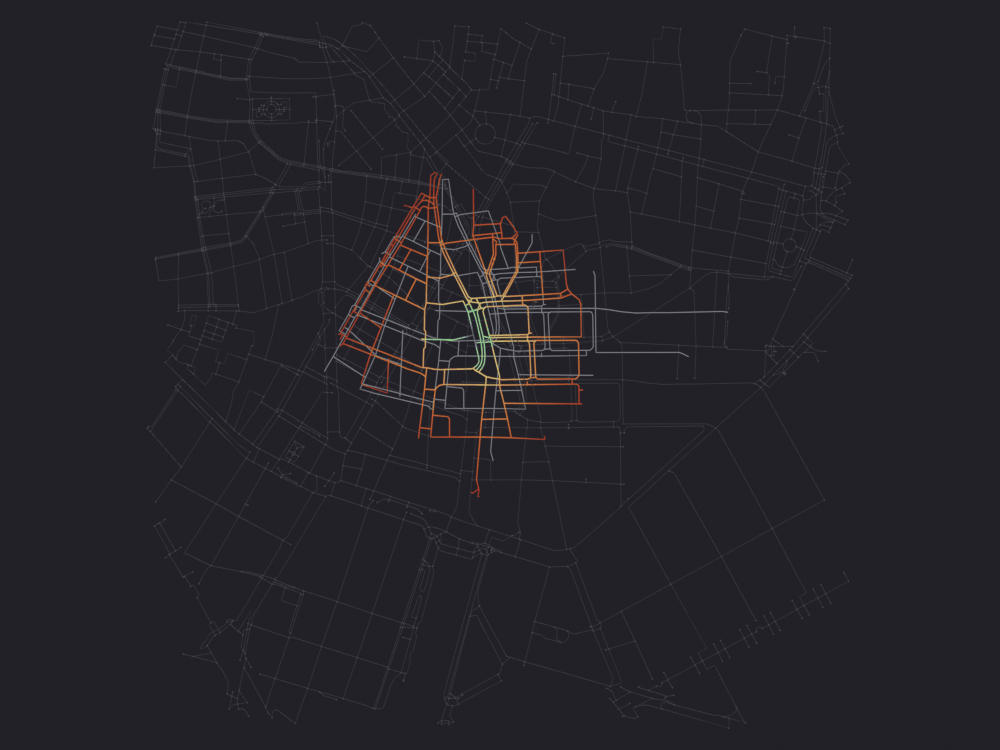

[PASS] 3_ego_hops_vs_metres.png legible — 7.3% ink (healthy range 0.5–60%)
  300 m ego                  median luminance 86, dimmest 5% at 46, 1.3% of the frame
  walk network               median luminance 47
  separation                 +38 levels


In [19]:
obj_ego_m = materialize(G.subgraph(meter_sets[300.0]).copy(), "Ego_300m")
obj_ego_h = materialize(G.subgraph(hop_sets[BEST_HOPS]).copy(),
                        f"Ego_{BEST_HOPS}hops")
node_attribute(obj_ego_m, meters_from_center, "node_meters")
print(f"300 m ego: {obj_ego_m['num_nodes']} nodes; "
      f"{BEST_HOPS}-hop ego: {obj_ego_h['num_nodes']} nodes; "
      f"in both: {len(meter_sets[300.0] & hop_sets[BEST_HOPS])}; "
      f"in one only: {len(meter_sets[300.0] ^ hop_sets[BEST_HOPS])}")

path, numbers = overlay(obj_net, obj_ego_m, "node_meters",
                        f"renders/{RENDERS}/3_ego_hops_vs_metres",
                        extra=[(obj_ego_h, 2.2, (0.42, 0.42, 0.48))])
nb.show(path)
nb.check_render(path)
report(numbers, "300 m ego", "walk network")

## 4 · The places, and getting them onto the network

Six operators download OSM features: `osmnx_features_place`,
`osmnx_features_point`, `osmnx_features_bbox`, `osmnx_features_address`,
`osmnx_features_polygon` (a Blender mesh reprojected) and `osmnx_features_xml`
(a local `.osm` file, no request at all). Six front doors onto one Overpass
request, differing only in how the area is named, all resolving a tag dict
through `SciGraphs/core/feature_tags.py`.

In [20]:
feature_tags = importlib.import_module("scigraphs_core.feature_tags")
print("presets:")
for name, tags in feature_tags.FEATURE_TAG_PRESETS.items():
    print(f"  {name:<18} {tags}")

presets:
  BUILDING           {'building': True}
  AMENITY            {'amenity': True}
  RESTAURANT         {'amenity': ['restaurant']}
  SHOP               {'shop': True}
  LEISURE            {'leisure': True}
  PARKING            {'amenity': ['parking']}
  BUS_STOP           {'highway': ['bus_stop']}
  RAIL_STATION       {'railway': ['station', 'halt', 'stop', 'tram_stop']}
  PARK               {'leisure': ['park', 'garden', 'nature_reserve', 'playground']}
  EDUCATION          {'amenity': ['school', 'university', 'college', 'kindergarten', 'library']}
  HEALTH             {'amenity': ['hospital', 'clinic', 'doctors', 'pharmacy', 'dentist']}
  AMENITY_METAPATH   {'amenity': ['cafe', 'restaurant', 'pub', 'bar', 'museum', 'theatre', 'cinema']}
  LANDUSE            {'landuse': True}
  NATURAL            {'natural': True}
  WATER              {'natural': ['water']}
  HIGHWAY            {'highway': True}


> **The custom-tag parser cannot express a multi-value tag.**
> `tags_from_preset` splits on commas and then on the first `=`, and assigns
> into a dict (`feature_tags.py:88-97`). So `amenity=cafe,amenity=bar` does
> not mean "cafes and bars": the second assignment replaces the first and you
> get bars. Every multi-value query in the add-on is therefore a preset, and
> `CUSTOM` can only ever ask for one value per key. Nothing warns.

In [21]:
print("amenity=cafe,amenity=bar  ->",
      feature_tags.tags_from_preset('CUSTOM', "amenity=cafe,amenity=bar"))
print("shop=true,amenity=bar     ->",
      feature_tags.tags_from_preset('CUSTOM', "shop=true,amenity=bar"))
check("a repeated key silently keeps only the last value",
      feature_tags.tags_from_preset('CUSTOM', "amenity=cafe,amenity=bar")
      == {"amenity": "bar"})

amenity=cafe,amenity=bar  -> {'amenity': 'bar'}
shop=true,amenity=bar     -> {'shop': True, 'amenity': 'bar'}
[PASS] a repeated key silently keeps only the last value


True

### One real call

`osmnx_features_point` with the `RESTAURANT` preset, the tightest tag set in
the table, over the same 600 m, so the download path is exercised end to end.
Overpass is a shared public service and this is the only request the suite
adds to it, so the tags are one key with one value and the radius is the study
radius and not a meter more. It is wrapped because `Errno 111` and `HTTP 429`
are the server rather than the code; the section continues on the cached
amenity set either way.

**`feat_source` has to be set first, and it is not an argument.** All six
operators consult `context.scene.scigraphs.feat_source` and, if it says
`OVERTURE` (the default), hand the query to city2graph's Overture reader
instead (`features_operators.py:234-241`), whatever the operator is called.
Left alone, `osmnx_features_point` talks to the Overture demo endpoint, which
answers `HTTP 400: Demo accounts can only access locations within 10,000
meters of demo cities` and reports "No features found".

In [22]:
props.feat_source = 'OSMNX'
props.feat_type = 'RESTAURANT'
props.feat_custom_tags = ""
props.feat_nodes_only = True

restaurants = None
try:
    result = bpy.ops.scigraphs.osmnx_features_point(
        latitude=CENTER[0], longitude=CENTER[1], distance=RADIUS_M,
        feature_type='RESTAURANT', filter_nodes_only=True)
    print("osmnx_features_point ->", result)
    restaurants = next((o for o in bpy.data.objects
                       if o.get("feature_type") == 'RESTAURANT'), None)
    if restaurants is not None:
        LAYERS.append(restaurants)
        print(f"  object {restaurants.name}: {len(restaurants.data.vertices)} "
              f"points, crs {restaurants.get('crs')}")
except RuntimeError as exc:
    print(f"the feature download did not happen: {exc}")
    print("carrying on with the cached amenity set below")

Downloaded 245 features from point
Info: Downloading features...
Info: Filtered to nodes only: 245 → 243 features
Info: Created 1 object(s) with 243 features
osmnx_features_point -> {'FINISHED'}
  object OSM_RESTAURANT: 243 points, crs epsg:4326


> The coordinates that went over the wire are not the literals
> above. `latitude` and `longitude` are Blender `FloatProperty` fields, single
> precision, so `39.4699` becomes `39.46989822387695`, and OSMnx keys its disk
> cache on the query string built from that. The study area moves by about a
> centimeter and the cache entry is a different file. So no operator-issued
> feature query can hit a cache entry warmed by a direct
> `ox.features_from_point` call, which is why this notebook spends one request
> rather than none.

### The POIs the rest of the section uses

Notebook 17's amenity query, unchanged, so it is a cache hit and section 6 is
a comparison rather than an approximation.

In [23]:
AMENITY_TAGS = {"amenity": ["restaurant", "cafe", "bar", "pub", "cinema",
                "theatre"]}
pois = ox.features_from_point(CENTER, tags=AMENITY_TAGS, dist=RADIUS_M)
pois = pois[pois.geometry.geom_type == "Point"].copy()
print(f"{len(pois)} point amenities")
print(pois["amenity"].value_counts().to_string())

objects = sg_geo_mesh.create_feature_mesh_from_gdf(
    pois[["amenity", "geometry"]], name="Amenities", osmnx_obj=obj_net)
obj_pois = objects[0]
LAYERS.append(obj_pois)
print(f"\nBlender object {obj_pois.name}: {len(obj_pois.data.vertices)} vertices")
check("one mesh vertex per amenity",
      len(obj_pois.data.vertices) == len(pois))

395 point amenities
amenity
restaurant    243
cafe          100
bar            31
pub            18
theatre         2
cinema          1

Blender object Amenities: 395 vertices
[PASS] one mesh vertex per amenity


True

### Snapping, and the distribution it produces

`osmnx_snap_pois` converts each vertex of the active mesh back to lon/lat,
asks `find_nearest_node` for the closest graph node, and writes the answer as
an integer point attribute. Three modes: record the id only, move the POI onto
the node, or draw a connector line to it.

It does not record how far it moved anything. A restaurant 12 m from the
nearest intersection is on that street corner. One 90 m from it is mid-block,
or in a pedestrian precinct the `walk` filter did not keep, or geocoded to a
building centroid whose entrance is elsewhere. Attaching it to an intersection
90 m away and computing a 15-minute reach from there adds 68 s of walking that
nobody does.

> **Which network it snaps to is not something you choose.**
> `_find_osmnx_object` (`features_operators.py:13-21`) returns the active
> object when that is a network, and otherwise the first object in
> `bpy.data.objects` carrying `is_osmnx`, which is alphabetical order. The
> active object here has to be the POI mesh, so the second branch decides. By
> this point the scene holds four networks (the walk graph, its 10-minute
> subgraph and the two ego subgraphs of section 3) and the one that wins is
> whichever name sorts first. Snapping 395 amenities to a 198-node fragment
> instead of to the network is a different answer, arrived at in silence.

In [24]:
def snapped_ids(obj):
    layer = obj.data.attributes["nearest_node_id"]
    return np.array([layer.data[i].value for i in range(len(obj.data.vertices))],
                    dtype=np.int64)


props.osmnx_poi_snap_mode = 'ATTR_ONLY'
candidates = [o.name for o in bpy.data.objects if o.get("is_osmnx")]
print("networks the scan can see:", candidates)
print("the one it will therefore pick:", candidates[0])

sg.graphs.activate(obj_pois)
# `find_nearest_node` logs once per call, and there are 395 calls.
with nb.quiet():
    first = bpy.ops.scigraphs.osmnx_snap_pois()
print("osmnx_snap_pois ->", first)
by_whichever = snapped_ids(obj_pois)

# The same scan with the fragments hidden; nothing else changes.
others = [o for o in bpy.data.objects
          if o.get("is_osmnx") and o is not obj_net]
for other in others:
    other["is_osmnx"] = False
sg.graphs.activate(obj_pois)
t0 = time.time()
with nb.quiet():
    second = bpy.ops.scigraphs.osmnx_snap_pois()
elapsed = time.time() - t0
for other in others:
    other["is_osmnx"] = True
print(f"osmnx_snap_pois, walk network only -> {second} in {elapsed:.1f} s "
      f"({len(pois)} POIs x {G.number_of_nodes()} nodes, one query each)")

by_walk = snapped_ids(obj_pois)
print(f"the two runs disagree on {int((by_whichever != by_walk).sum())} "
      f"of {len(by_walk)} amenities, and neither reported anything unusual")

nearest_id, nearest_m = ox.distance.nearest_nodes(
    G, X=pois.geometry.x.values, Y=pois.geometry.y.values, return_dist=True)
nearest_id = np.asarray(nearest_id, dtype=np.int64)
nearest_m = np.asarray(nearest_m, dtype=float)

print("\nsnap distance to the nearest intersection, meters:")
for q in (5, 25, 50, 75, 90, 95, 99, 100):
    print(f"  p{q:<3} {np.percentile(nearest_m, q):7.1f}")
print(f"  mean {nearest_m.mean():.1f}   over 50 m: "
      f"{int((nearest_m > 50).sum())}   over 80 m: {int((nearest_m > 80).sum())}")

networks the scan can see: ['Ego_300m', 'Ego_8hops', 'Reach_10min', 'Walk_CiutatVella']
the one it will therefore pick: Ego_300m
Nearest node to (39.47035612802079, -0.38104359582998154): 593993799
Nearest node to (39.47024962802094, -0.380592400153335): 593993799
Nearest node to (39.47052772801409, -0.3795815096319921): 593993799
Nearest node to (39.47031262802067, -0.3800625050654201): 593993799
Nearest node to (39.47035892802078, -0.37985670724375314): 593993799
Nearest node to (39.47024492801946, -0.3804027021163787): 593993799
Nearest node to (39.47023712802129, -0.3822678842740743): 593993799
Nearest node to (39.47169732802357, -0.38032940263074494): 593993789
Nearest node to (39.47084972802113, -0.38047590126262404): 593993799
Nearest node to (39.47417042791904, -0.3814178923020346): 593995484
Nearest node to (39.47360522788909, -0.38041090182342646): 593995484
Nearest node to (39.473077328025, -0.38104779584929627): 593995484
Nearest node to (39.47386112814677, -0.3816077906705

The tail is not noise. The furthest amenities are the ones the
network filter cannot see: a `walk` download keeps footways and pedestrian
streets but not the interior of a market hall or a private courtyard.

In [25]:
order = np.argsort(-nearest_m)[:5]
for i in order:
    row = pois.iloc[i]
    name = str(row.get("name"))
    print(f"  {nearest_m[i]:6.1f} m  {str(row.get('amenity')):<11} "
          f"{(name if name != 'nan' else '(unnamed)')[:34]}")

    99.3 m  restaurant  La Gallineta
    77.4 m  restaurant  Voltereta Manhattan
    75.5 m  restaurant  Restaurant mediterran
    71.2 m  restaurant  (unnamed)
    66.0 m  restaurant  Bai Wei Xuan


### Snapping to a node is not snapping to the street

The distribution above is against intersections, because that is what a graph
node is. The distance to the nearest street edge is a much smaller number, and
the gap between the two is the length of a city block, not a data-quality
problem. It is also why routing operators take an edge and accessibility
operators take a node.

Measured on a projected copy, because `ox.distance.nearest_edges` returns
distances in the graph's own units (meters when projected, degrees when not)
while `nearest_nodes` returns meters either way.

In [26]:
G_metric = ox.project_graph(G, to_crs=METRIC_CRS)
px, py = to_utm.transform(pois.geometry.x.values, pois.geometry.y.values)
_edges, edge_m = ox.distance.nearest_edges(G_metric, X=px, Y=py, return_dist=True)
edge_m = np.asarray(edge_m, dtype=float)
print(f"to the nearest node : median {np.median(nearest_m):5.1f} m  "
      f"p95 {np.percentile(nearest_m, 95):5.1f} m")
print(f"to the nearest edge : median {np.median(edge_m):5.1f} m  "
      f"p95 {np.percentile(edge_m, 95):5.1f} m")
print(f"ratio at the median : {np.median(nearest_m) / max(np.median(edge_m), 1e-9):.1f}x")

to the nearest node : median  12.9 m  p95  40.3 m
to the nearest edge : median   5.1 m  p95  15.4 m
ratio at the median : 2.6x


### What the operator actually wrote

It stores the nearest node id as an `INT` point attribute
(`features_operators.py:696`), and Blender's `INT` attribute is 32-bit. Modern
OpenStreetMap node ids are not: they passed 2³¹ years ago, and 746 of the 1472
intersections in this graph are above it. The assignment at
`features_operators.py:719` is wrapped in
`except (TypeError, ValueError): nattr.data[i].value = -1` (`:720-721`), so
every POI whose nearest intersection has a modern id is silently recorded as
unsnapped and the operator reports success for all of them.

In [27]:
written = by_walk
too_big = nearest_id > 2 ** 31 - 1
missing = written == -1
print(f"graph node ids run {int(min(G.nodes))} … {int(max(G.nodes))}; "
      f"the int32 ceiling is {2 ** 31 - 1}")
print(f"intersections above the int32 ceiling: "
      f"{sum(1 for n in G.nodes if n > 2 ** 31 - 1)} of {G.number_of_nodes()}")
print(f"POIs recorded as -1: {int(missing.sum())} of {len(written)} "
      f"({100 * missing.mean():.1f}%)")
print(f"  of which the true nearest node is above the ceiling: "
      f"{int((missing & too_big).sum())}")
print(f"POIs recorded with an id: {int((~missing).sum())}, agreeing with "
      f"ox.distance.nearest_nodes on {int((written[~missing] == nearest_id[~missing]).sum())}")

check("every -1 is an int32 overflow, not a failed query",
      bool((missing == too_big).all()),
      f"{int(missing.sum())} POIs lost to a 32-bit attribute")
check("the ids it does write are correct",
      bool((written[~missing] == nearest_id[~missing]).all()),
      "so the geometry and the query are fine; only the storage is not")

graph node ids run 25767290 … 13970549071; the int32 ceiling is 2147483647
intersections above the int32 ceiling: 746 of 1472
POIs recorded as -1: 170 of 395 (43.0%)
  of which the true nearest node is above the ceiling: 170
POIs recorded with an id: 225, agreeing with ox.distance.nearest_nodes on 225
[PASS] every -1 is an int32 overflow, not a failed query — 170 POIs lost to a 32-bit attribute
[PASS] the ids it does write are correct — so the geometry and the query are fine; only the storage is not


True

> The coordinate round trip, at least, is exact.
> `blender_to_lonlat` (`features_operators.py:684-687`) inverts the same
> equirectangular projection `_convert_osmnx_coords_to_3d` used to build the
> mesh, from the same origin (`get_graph_extent`'s mean of the node
> coordinates), so a POI comes back within a hundredth of a millimeter of
> where it started. The `ADD_CONNECTOR` and `MOVE_TO_NODE` modes read
> `node_positions` through `int(nid)` in plain Python and are unaffected by
> the ceiling; only the recorded attribute is lost.

In [28]:
mpd = math.pi / 180.0 * 6371000.0
cos_lat = math.cos(math.radians(lat0))
scale = obj_net.get("osmnx_scale", 0.001)
back_lat = np.array([lat0 + v.co.y / scale / mpd for v in obj_pois.data.vertices])
back_lon = np.array([lon0 + v.co.x / scale / (mpd * cos_lat)
                    for v in obj_pois.data.vertices])
_a, _b, round_trip = GEOD.inv(pois.geometry.x.values, pois.geometry.y.values,
                              back_lon, back_lat)
print(f"round-trip position error: median {np.median(round_trip) * 1000:.3f} mm, "
      f"max {round_trip.max() * 1000:.3f} mm")

round-trip position error: median 0.007 mm, max 0.033 mm


### The figure

One edge from each amenity to the intersection it was attached to, colored by
how far that was, drawn over the street network in the flat neutral. The top
percentile is clipped: a handful of 70 to 100 m outliers would otherwise take
the whole top of the ramp and press the ordinary 10 m snaps into the bottom
stop.

{'object': 'POI_Connectors', 'type': 'MESH', 'num_nodes': 685, 'num_edges': 395, 'is_directed': False, 'vertices': 685, 'mesh_edges': 395, 'attributes': ['position', '.edge_verts', '.corner_vert', '.corner_edge', 'node_id', 'node_snap_m', 'edge_length_m'], 'graph_type': 'osmnx_snap_pois'}
  Promoted 1 edge attribute(s) to point domain for GN propagation
Info: Geometry Nodes modifier added
Info: Attribute -> node_snap_m  ·  node_snap_m -> turbo [log]  [0 … 43.59] on Point
  Skipping Split Edges: 'is_intersection' present, keeping streets continuous
Info: Geometry Nodes modifier added
  Skipping Split Edges: 'is_intersection' present, keeping streets continuous
Info: Geometry Nodes modifier added


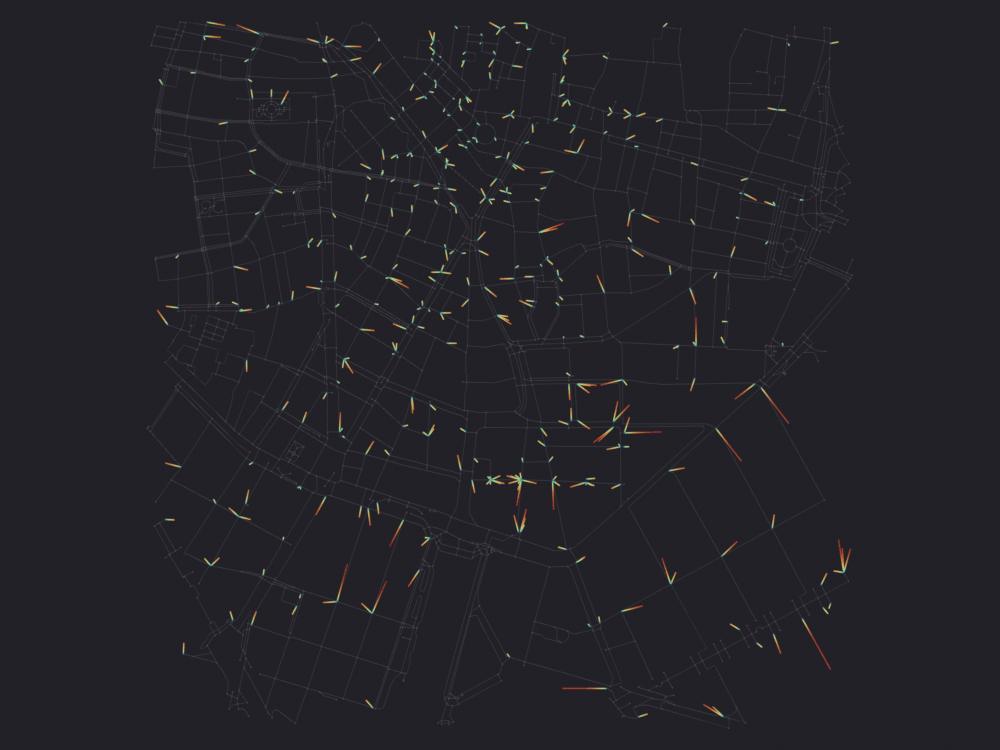

[PASS] 4_poi_snapping.png legible — 6.4% ink (healthy range 0.5–60%)
  amenities and connectors   median luminance 97, dimmest 5% at 45, 1.4% of the frame
  street network             median luminance 47
  separation                 +50 levels


In [29]:
anchor = sg.graphs.anchor(obj_net["osmnx_center_lat"], obj_net["osmnx_center_lon"],
                          scale=obj_net.get("osmnx_scale", 0.001),
                          name="Anchor_Accessibility")

snap_nodes = {}
for i, node_id in enumerate(nearest_id):
    snap_nodes[f"poi_{i}"] = (pois.geometry.iloc[i], float(nearest_m[i]))
    if node_id not in snap_nodes:
        snap_nodes[node_id] = (
            __import__("shapely").geometry.Point(G.nodes[node_id]["x"],
                                                 G.nodes[node_id]["y"]), 0.0)

snap_gdf = gpd.GeoDataFrame(
    {"snap_m": [v[1] for v in snap_nodes.values()]},
    geometry=[v[0] for v in snap_nodes.values()],
    index=list(snap_nodes.keys()), crs="EPSG:4326")
connector_gdf = gpd.GeoDataFrame(
    {"length_m": nearest_m},
    geometry=[LineString([pois.geometry.iloc[i],
              (G.nodes[nearest_id[i]]["x"], G.nodes[nearest_id[i]]["y"])])
              for i in range(len(pois))],
    index=pd.MultiIndex.from_tuples([(f"poi_{i}", nearest_id[i])
                                    for i in range(len(pois))]),
    crs="EPSG:4326")

obj_connect = sg.graphs.from_gdf(snap_gdf, connector_gdf, name="POI_Connectors",
                                 ref=anchor, coll="NB13_Accessibility",
                                 markers={"graph_type": "osmnx_snap_pois"})
LAYERS.append(obj_connect)
print(sg.graphs.summary(obj_connect))

path, numbers = overlay(obj_net, obj_connect, "node_snap_m",
                        f"renders/{RENDERS}/4_poi_snapping",
                        clip_high_pct=98)
nb.show(path)
nb.check_render(path)
report(numbers, "amenities and connectors", "street network")

## 5 · Distance on the network, not in the plane

`osmnx_network_dbscan` clusters the graph's nodes with DBSCAN on a precomputed
distance matrix built from `all_pairs_dijkstra_path_length`
(`accessibility.py:220-234`). `eps` is a distance along the streets, so two
points either side of a river, a railway or a walled block are far apart
however close they look on a map.

The detour factor, below, is the ratio of a node's shortest network distance
to the center to its straight-line distance: 1.0 on a node you can walk to
directly, unbounded on one you cannot.

In [30]:
nodes_metric = ox.graph_to_gdfs(G, edges=False).to_crs(METRIC_CRS)
xy = np.c_[nodes_metric.geometry.x.values, nodes_metric.geometry.y.values]
node_ids = list(G.nodes)
position = {n: i for i, n in enumerate(node_ids)}

t0 = time.time()
all_pairs = dict(nx.all_pairs_dijkstra_path_length(G, weight="length"))
network_d = np.full((len(node_ids), len(node_ids)), np.inf, dtype=np.float32)
for source, rest in all_pairs.items():
    i = position[source]
    for target, meters in rest.items():
        network_d[i, position[target]] = meters
# What the operator does (`accessibility.py:232`): the shorter of the two
# directions. A no-op on a pedestrian graph, an understatement on a one-way
# drive network.
network_d = np.minimum(network_d, network_d.T)
straight = np.sqrt(((xy[:, None, :] - xy[None, :, :]) ** 2).sum(-1))
print(f"all-pairs shortest paths on {len(node_ids)} nodes: {time.time() - t0:.1f} s "
      f"({network_d.nbytes / 1e6:.1f} MB, and it is O(n^2))")

center_i = position[center_node]
detour = np.where(straight[center_i] > 30.0,
                  network_d[center_i] / np.maximum(straight[center_i], 1e-9), 1.0)
print(f"\ndetour factor from the center: median {np.median(detour):.2f}, "
      f"p95 {np.percentile(detour, 95):.2f}, max {detour.max():.2f}")

all-pairs shortest paths on 1472 nodes: 5.3 s (8.7 MB, and it is O(n^2))

detour factor from the center: median 1.21, p95 1.44, max 2.05


### Where the two metrics disagree most

Not at long range: over a kilometer the street grid averages out and the
detour factor settles near 1.2. The disagreement is local, between pairs of
nodes a few dozen meters apart on opposite sides of something you cannot
cross.

In [31]:
window = (straight > 40.0) & (straight < 200.0) & np.isfinite(network_d)
ratio = np.where(window, network_d / np.maximum(straight, 1.0), 0.0)
print(f"pairs 40-200 m apart on the map: {int(window.sum()) // 2:,}")
print(f"  of which the walk is more than 5x the straight line: "
      f"{int((ratio > 5).sum()) // 2:,}")

nodes_wgs = ox.graph_to_gdfs(G, edges=False)
flat = np.argsort(-ratio, axis=None)[:200]
seen = set()
shown = 0
print(f"\n{'straight':>9}  {'on foot':>9}  {'ratio':>6}   node and where")
for k in flat:
    i, j = np.unravel_index(k, ratio.shape)
    if (j, i) in seen:
        continue
    seen.add((i, j))
    print(f"{straight[i, j]:>7.0f} m  {network_d[i, j]:>7.0f} m  "
          f"{ratio[i, j]:>6.1f}   {node_ids[i]} at "
          f"{nodes_wgs.geometry.iloc[i].y:.5f}, "
          f"{nodes_wgs.geometry.iloc[i].x:.5f}")
    shown += 1
    if shown >= 4:
        break

check("network distance and straight-line distance genuinely disagree",
      int((ratio > 5).sum()) // 2 > 100,
      "hundreds of pairs within 200 m need a detour of more than 5x")

pairs 40-200 m apart on the map: 92,552
  of which the walk is more than 5x the straight line: 375

 straight    on foot   ratio   node and where
     41 m      773 m    19.0   10896195456 at 39.46480, -0.37396
     44 m      794 m    18.1   10896195449 at 39.46489, -0.37374
     40 m      683 m    16.9   29834290 at 39.46796, -0.38312
     44 m      685 m    15.7   4443555083 at 39.46526, -0.37329
[PASS] network distance and straight-line distance genuinely disagree — hundreds of pairs within 200 m need a detour of more than 5x


True

### The figure

The network colored by the detour factor from the center, interpolated along
each street the way section 1 explains. Read against figure 1 it is the same
map with the radial component divided out: dark blue is a street the center
reaches as directly as a bird would, every warm run a place where the network
makes you go round something.

The top percentile is clipped, and here it buys less than usual: a detour
costing twenty times the straight line is a local fact about two nearby nodes,
so from a single well-connected origin the factor stops at about 2. The
pairwise view finds 375 pairs over 5x; this one finds a maximum of 2.

  Skipping Split Edges: 'is_intersection' present, keeping streets continuous
Info: Geometry Nodes modifier added
Info: Attribute -> node_detour  ·  node_detour -> turbo [log]  [1 … 1.57] on Point


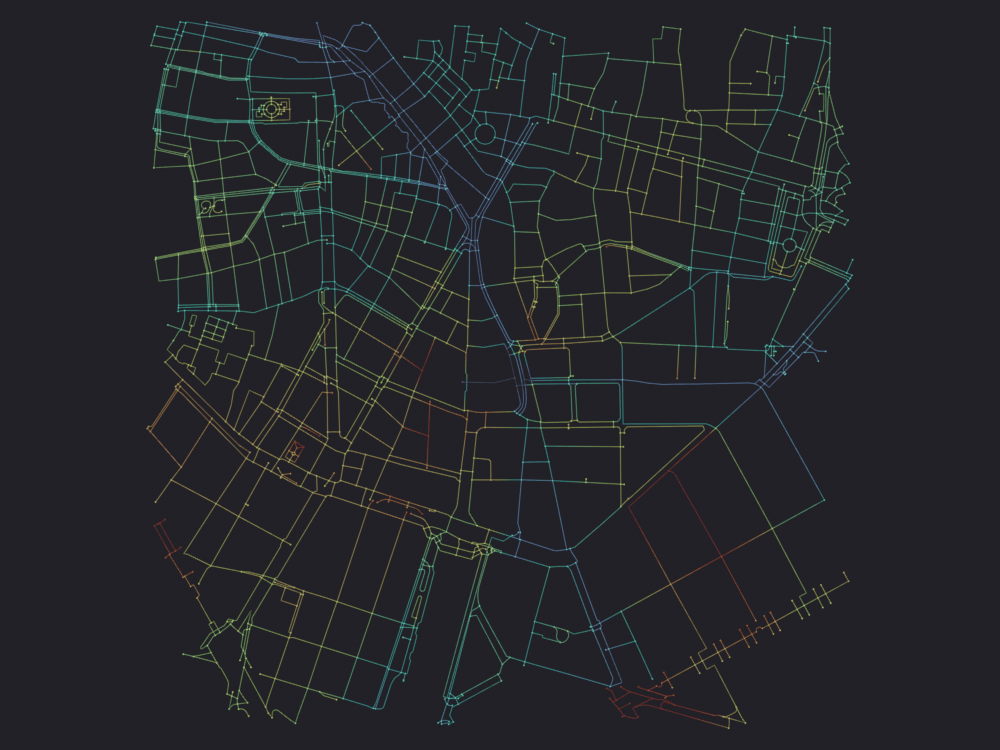

[PASS] 5_detour.png legible — 9.3% ink (healthy range 0.5–60%)


In [32]:
node_attribute(obj_net, {n: float(detour[position[n]]) for n in node_ids},
               "node_detour")
plain(obj_net)
nb.figure(obj_net, f"renders/{RENDERS}/5_detour",
          look='ink', color_attribute="node_detour",
          nodes_only=False, clip_high_pct=98,
          node_fraction=NODE_FRACTION,
          hide=[o for o in LAYERS if o is not obj_net])

### DBSCAN, both ways

The same algorithm, `eps` and `min_samples` on the same 1472 nodes, once with
network distance and once with straight-line distance. The adjusted Rand index
compares the two partitions: 1.0 is identical, 0.0 is chance.

In [33]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import adjusted_rand_score

print(f"{'eps':>5}  {'network':>18}  {'straight line':>18}  {'ARI':>6}")
sweep = {}
for eps in (60, 80, 100, 120):
    labels = sg_access.network_dbscan(G, eps_meters=float(eps), min_samples=5,
                                      weight="length")
    net = np.array([labels[n] for n in node_ids])
    euclid = DBSCAN(eps=float(eps), min_samples=5).fit_predict(xy)
    sweep[eps] = (net, euclid)
    print(f"{eps:>5}  {len(set(net) - {-1}):>3} clusters, {int((net == -1).sum()):>3} "
          f"noise  {len(set(euclid) - {-1}):>3} clusters, "
          f"{int((euclid == -1).sum()):>3} noise  "
          f"{adjusted_rand_score(net, euclid):>6.3f}")

net_80, euclid_80 = sweep[80]
check("the two metrics find different structure",
      len(set(net_80) - {-1}) > len(set(euclid_80) - {-1}),
      "the network metric splits what the plane merges")

  eps             network       straight line     ARI
   60   15 clusters,  55 noise   13 clusters,  27 noise   0.960
   80    7 clusters,  20 noise    3 clusters,   7 noise   0.835
  100    3 clusters,   7 noise    1 clusters,   3 noise   0.073
  120    2 clusters,   4 noise    1 clusters,   3 noise   0.077
[PASS] the two metrics find different structure — the network metric splits what the plane merges


True

At 60 m the two agree almost completely: at that range a street
is a straight line. As `eps` grows the plane starts jumping barriers the
network cannot; by 100 m the straight-line version has merged the whole
neighborhood into one cluster while the network version still holds it apart,
and the ARI has collapsed.

### What the operator writes onto the mesh

`osmnx_network_dbscan` also stores the labels as an `INT` point attribute.
Cluster ids are small, so nothing overflows. What goes wrong is the other end:
the attribute is created for every mesh vertex and written only for the first
`len(node_ids)` of them (`accessibility_operators.py:303-309`). The street
shape points keep Blender's default of `0`, which is not a sentinel but
cluster 0, the largest one.

In [34]:
sg.graphs.activate(obj_net)
t0 = time.time()
print("osmnx_network_dbscan ->",
      bpy.ops.scigraphs.osmnx_network_dbscan(eps=80.0, min_samples=5),
      f"in {time.time() - t0:.1f} s")
print(f"  {obj_net['osmnx_dbscan_clusters']} clusters, "
      f"{obj_net['osmnx_dbscan_noise']} noise")

raw = obj_net.data.attributes["dbscan_cluster"]
labels_mesh = np.array([raw.data[i].value for i in range(len(obj_net.data.vertices))])
marker = obj_net.data.attributes["is_intersection"]
is_node = np.array([marker.data[i].value
                   for i in range(len(obj_net.data.vertices))]) != 0
print(f"  mesh vertices {len(labels_mesh)}, of which intersections "
      f"{int(is_node.sum())}")
print(f"  values on the {int((~is_node).sum())} street shape vertices: "
      f"{np.unique(labels_mesh[~is_node])}")
check("the shape vertices default into cluster 0",
      bool((labels_mesh[~is_node] == 0).all()) and 0 in set(net_80),
      f"{int((~is_node).sum())} vertices join the largest cluster silently")

Info: DBSCAN: 7 clusters, 20 noise points
osmnx_network_dbscan -> {'FINISHED'} in 4.9 s
  7 clusters, 20 noise
  mesh vertices 3444, of which intersections 1472
  values on the 1972 street shape vertices: [0]
[PASS] the shape vertices default into cluster 0 — 1972 vertices join the largest cluster silently


True

The figure needs the shape vertices filled honestly instead. A
cluster id is not a quantity, so the mean of two labels is meaningless: a
street between cluster 2 and cluster 5 is not in cluster 3.5.
`fill='endpoint'` gives a street its cluster when both ends agree and marks it
noise when they do not. A segment bridging two clusters belongs to neither.

street vertices between two different clusters: 127 of 1972
  Skipping Split Edges: 'is_intersection' present, keeping streets continuous
Info: Geometry Nodes modifier added
Info: Attribute -> node_cluster  ·  node_cluster -> turbo [log]  [-1 … 6] on Point


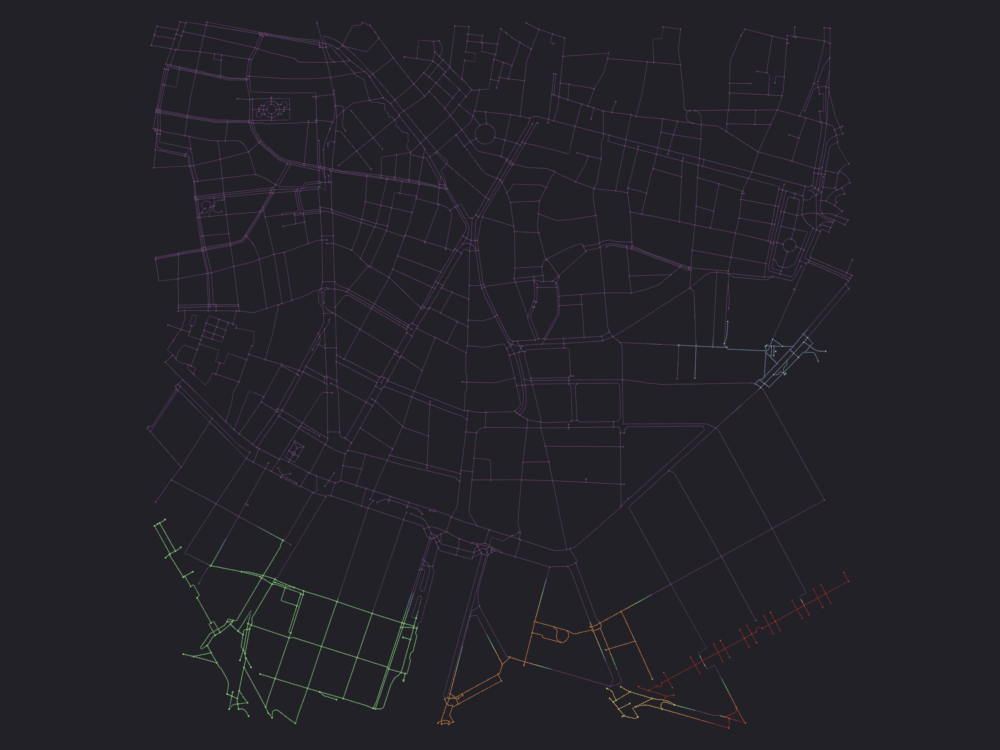

[PASS] 6_network_clusters.png legible — 7.1% ink (healthy range 0.5–60%)


In [35]:
cluster_of = {n: float(v) for n, v in
              sg_access.network_dbscan(G, eps_meters=80.0, min_samples=5,
              weight="length").items()}
written, filled = node_attribute(obj_net, cluster_of, "node_cluster",
                                 fill="endpoint", default=-1.0)
bridging = int((filled[~is_node] == -1).sum())
print(f"street vertices between two different clusters: {bridging} of "
      f"{int((~is_node).sum())}")

plain(obj_net)
nb.figure(obj_net, f"renders/{RENDERS}/6_network_clusters",
          look='ink', color_attribute="node_cluster",
          nodes_only=False, node_fraction=NODE_FRACTION,
          hide=[o for o in LAYERS if o is not obj_net])

## 6 · The same fifteen minutes, twice

Notebook 17 answers the same question with `c2g.create_isochrone`, on a graph
built by `c2g.gdf_to_nx` from the same OSMnx download, with `travel_time`
derived from `length` at the same 4.8 km/h. Two implementations sharing no
code below `networkx`.

They are not given the same graph:

| | OSMnx path | city2graph path (notebook 17) |
|---|---|---|
| graph | the `MultiDiGraph` as downloaded | rebuilt from two GeoDataFrames |
| direction | directed | undirected |
| parallel edges | kept, cheapest wins in the weight function | dropped: 05 deduplicates on `(u, v)` keeping the shortest |
| node identity | OSM ids | renumbered 0 to n-1 by `gdf_to_nx` |
| cost | `travel_time`, imputed from `length` | `travel_time`, computed from `length` |

In [36]:
connectors = ox.graph_to_gdfs(G, edges=False).to_crs(METRIC_CRS)[["geometry"]]
connectors.index.name = "connector_id"
edges_ox = ox.graph_to_gdfs(G, nodes=False)
segments = (edges_ox.to_crs(METRIC_CRS).reset_index()
            .sort_values("length")
            .drop_duplicates(subset=["u", "v"])
            .set_index(["u", "v"])[["length", "geometry"]])
segments["travel_time"] = segments["length"] / SPEED_MS

parallel = edges_ox.reset_index().groupby(["u", "v"]).size()
undirected_pairs = {(min(u, v), max(u, v)) for u, v, _k in edges_ox.index}
print(f"osmnx directed edges          {len(edges_ox)}")
print(f"  (u, v) pairs with a parallel {int((parallel > 1).sum())}")
print(f"  distinct undirected pairs    {len(undirected_pairs)}")
print(f"c2g segments after 05's dedup  {len(segments)}")

G_c2g = c2g.gdf_to_nx(nodes=connectors, edges=segments)
print(f"c2g graph: {G_c2g.number_of_nodes()} nodes, "
      f"{G_c2g.number_of_edges()} edges, directed={G_c2g.is_directed()}")

osmnx directed edges          4396
  (u, v) pairs with a parallel 40
  distinct undirected pairs    2178
c2g segments after 05's dedup  4354
c2g graph: 1472 nodes, 2178 edges, directed=False


> `gdf_to_nx` renumbers the nodes. The graph it returns is keyed
> 0 to n-1 in the order of the `nodes` GeoDataFrame, and the OSM id survives
> only as the `_original_index` node attribute. That is why notebook 05 passes
> `create_isochrone` a geometry rather than a node id, and the first thing to
> sort out before the two answers can be compared.

In [37]:
c2g_to_osm = {n: G_c2g.nodes[n].get("_original_index") for n in G_c2g.nodes}
check("the c2g renumbering is positional",
      all(c2g_to_osm[i] == connectors.index[i] for i in range(len(connectors))),
      f"node 0 is {c2g_to_osm[0]}")
center_c2g = next(k for k, v in c2g_to_osm.items() if v == center_node)

[PASS] the c2g renumbering is positional — node 0 is 25767290


### The reachable sets

In [38]:
d_c2g = {c2g_to_osm[k]: v for k, v in
         nx.single_source_dijkstra_path_length(G_c2g, center_c2g,
         weight="travel_time").items()}
print(f"{'budget':>7}  {'osmnx':>7}  {'c2g':>7}  {'osmnx only':>11}  "
      f"{'c2g only':>9}  {'Jaccard':>8}")
for budget in (300, 600, 900):
    a = {n for n, s in seconds.items() if s <= budget}
    b = {n for n, s in d_c2g.items() if s <= budget}
    print(f"{budget:>6} s  {len(a):>7}  {len(b):>7}  {len(a - b):>11}  "
          f"{len(b - a):>9}  {len(a & b) / len(a | b):>8.4f}")

common = [n for n in seconds if n in d_c2g]
delta = np.array([seconds[n] - d_c2g[n] for n in common])
print(f"\nper-node cost difference, seconds:")
print(f"  largest absolute {np.abs(delta).max():.3e}")
print(f"  nodes differing by more than a millisecond: "
      f"{int((np.abs(delta) > 1e-3).sum())} of {len(delta)}")
print(f"  nodes differing at all (floating point): "
      f"{int((delta != 0).sum())}")

check("the two implementations agree on who is reachable",
      all({n for n, s in seconds.items() if s <= t}
      == {n for n, s in d_c2g.items() if s <= t}
      for t in (300, 600, 900)))
check("and on what it costs to get there",
      float(np.abs(delta).max()) < 1e-6,
      f"largest disagreement {np.abs(delta).max():.2e} s")

 budget    osmnx      c2g   osmnx only   c2g only   Jaccard
   300 s      332      332            0          0    1.0000
   600 s     1230     1230            0          0    1.0000
   900 s     1472     1472            0          0    1.0000

per-node cost difference, seconds:
  largest absolute 2.274e-13
  nodes differing by more than a millisecond: 0 of 1472
  nodes differing at all (floating point): 394
[PASS] the two implementations agree on who is reachable
[PASS] and on what it costs to get there — largest disagreement 2.27e-13 s


True

### Why they agree, which is not obvious

Three of the five differences do not matter here:

- Direction. OSMnx's `walk` filter marks every way two-way, so the directed
  and undirected graphs have the same reachability. That would not survive a
  `drive` network; section 3 measured the asymmetry.
- Parallel edges. 40 of 4354 `(u, v)` pairs carry more than one segment. The
  add-on's weight function takes the cheapest (`accessibility.py:104-112`);
  notebook 17 sorts by length and keeps the shortest. Same edge either way.
- Renumbering. Cosmetic, once mapped back.

What is left is the same Dijkstra over the same lengths at the same speed, and
the residue is floating point: the two paths sum the same segments in
different orders, nothing above a nanosecond. The reachable set is not where
the two answers differ; the polygon is.

In [39]:
center_geom = connectors.geometry.loc[center_node]
hull_c2g = c2g.create_isochrone(graph=G_c2g, center_point=center_geom,
                                threshold=[300, 600, 900],
                                edge_attr="travel_time", method="convex_hull")
buffer_c2g = c2g.create_isochrone(graph=G_c2g, center_point=center_geom,
                                  threshold=[300, 600, 900],
                                  edge_attr="travel_time", method="buffer",
                                  buffer_distance=25.0)

print(f"{'':<22}{'5 min':>10}{'10 min':>10}{'15 min':>10}   (km2)")
rows = [
    ("convex hull, c2g", [a / 1e6 for a in hull_c2g.geometry.area]),
    ("convex hull, add-on",
     [transform(to_utm.transform, polygons[("CONVEX_HULL", m)]).area / 1e6
     for m in (5, 10, 15)]),
    ("buffer 25 m, c2g", [a / 1e6 for a in buffer_c2g.geometry.area]),
    ("buffer 25 m, add-on",
     [transform(to_utm.transform, polygons[("BUFFER_UNION", m)]).area / 1e6
     for m in (5, 10, 15)]),
]
for label, areas in rows:
    print(f"{label:<22}" + "".join(f"{a:>10.4f}" for a in areas))

shortfall = [100 * (1 - b / a) for a, b in zip(rows[2][1], rows[3][1])]
print("\nthe add-on's buffer polygon is smaller by: "
      + ", ".join(f"{s:.1f}%" for s in shortfall))

check("the two convex hulls are the same polygon",
      all(abs(a - b) / a < 1e-6 for a, b in zip(rows[0][1], rows[1][1])),
      "both are the hull of the same reachable node set")
check("the two buffer polygons are not",
      all(s > 3.0 for s in shortfall),
      "the add-on's is short by roughly the anisotropy of section 2")

                           5 min    10 min    15 min   (km2)
convex hull, c2g          0.3096    1.1800    1.3712
convex hull, add-on       0.3096    1.1800    1.3712
buffer 25 m, c2g          0.3135    1.0833    1.2521
buffer 25 m, add-on       0.2980    1.0206    1.1861

the add-on's buffer polygon is smaller by: 5.0%, 5.8%, 5.3%
[PASS] the two convex hulls are the same polygon — both are the hull of the same reachable node set
[PASS] the two buffer polygons are not — the add-on's is short by roughly the anisotropy of section 2


True

### The disagreement, explained

The convex hulls are identical to six figures: two independent implementations
given the same reachable node set compute the same hull of it.

The buffer polygons differ by about 5 %, in one direction, at every threshold.
That is section 2's two faults arriving in the answer:

1. the buffer is `25 / 111000` degrees, which at this latitude is 25.0 m north
   to south and 19.4 m east to west, so the add-on's polygon is narrower
   across than it should be everywhere;
2. the buffered edges are straight lines between endpoints rather than street
   centerlines, so every bend loses a sliver.

Both push the same way, and neither is visible in anything the operator
reports.

It also exposes a fault of notebook 17's. Its 15-minute graph is a hairball
because "within a 600 m radius almost any amenity reaches almost any other in
15 minutes", which notebook 17 reads as a fact about the neighborhood. It is
a fact about the download: the furthest intersection here is 858 s from the
center, so a 900 s budget contains the whole of it, and would contain any
600 m download of anywhere.

In [40]:
print(f"eccentricity from the center : {reach.max():.0f} s")
print(f"the 15-minute budget         : {THRESHOLD_S} s")
print(f"a 900 s walk at {SPEED_KPH} km/h  : {THRESHOLD_S * SPEED_MS:.0f} m of network")
print(f"the download radius          : {RADIUS_M} m")
check("the 15-minute answer is bounded by the download, not the budget",
      reach.max() < THRESHOLD_S,
      "which is a property of the query, not of the city")

eccentricity from the center : 858 s
the 15-minute budget         : 900 s
a 900 s walk at 4.8 km/h  : 1200 m of network
the download radius          : 600 m
[PASS] the 15-minute answer is bounded by the download, not the budget — which is a property of the query, not of the city


True

## 7 · Saving

In [41]:
out_dir = nb.out(RENDERS)
out_dir.mkdir(parents=True, exist_ok=True)

isochrone_gdf = gpd.GeoDataFrame(
    {"minutes": [5, 10, 15],
     "mode": ["BUFFER_UNION"] * 3,
     "nodes": [int((reach <= m * 60).sum()) for m in (5, 10, 15)]},
    geometry=[polygons[("BUFFER_UNION", m)] for m in (5, 10, 15)],
    crs="EPSG:4326").to_crs(METRIC_CRS)

reach_gdf = ox.graph_to_gdfs(G, edges=False)[["geometry"]].copy()
reach_gdf["travel_time_s"] = [seconds.get(n, np.nan) for n in reach_gdf.index]
reach_gdf["detour"] = [float(detour[position[n]]) for n in reach_gdf.index]
reach_gdf["cluster_eps80"] = [int(cluster_of[n]) for n in reach_gdf.index]

snap_out = pois[["amenity", "geometry"]].copy()
snap_out["nearest_node"] = nearest_id
snap_out["snap_m"] = nearest_m
snap_out["recorded_by_operator"] = written

sg.graphs.save_gdf(isochrone_gdf, out_dir / "isochrones.gpkg")
sg.graphs.save_gdf(reach_gdf, out_dir / "nodes_reachability.gpkg")
sg.graphs.save_gdf(snap_out, out_dir / "amenities_snapped.gpkg")

print("written to", nb.rel(out_dir))
for f in sorted(out_dir.iterdir()):
    if f.is_file():
        print("  ", f.name, f"{f.stat().st_size / 1e3:.0f} kB")

written to notebooks/out/09_osmnx_accessibility
   amenities_snapped.gpkg 152 kB
   isochrones.gpkg 430 kB
   nodes_reachability.gpkg 270 kB


## Rendering

Six figures, all EEVEE through `sg.render`, all straight down through an
orthographic camera, all `look='ink'` and its turbo ramp on a near-black
backdrop, so a plate here can be laid beside one from notebook 17 or 11 and
only the data will have changed. Figures 2, 3 and 4 are the notebook 04
overlays of section 2, with tubes 4.0x the context's.

Two adjustments for an OSMnx mesh. `node_fraction=0.16` rather than the 0.35
default, which sizes a node sphere at 35 % of the median distance between
neighbors and is calibrated for an abstract graph on an empty field: on a
street network the context's own spheres swallow any highlight thinner than
they are, and they still have to read as a network, which rules out zero. And
the highlight's spheres go to 2 % of the context's, because both objects hold
real intersections at the same coordinates and the two would z-fight. Only the
tubes carry the highlight.

The `*_context.png` files in `out/renders/12_osmnx_accessibility/` are the
second render of each overlay pair, measurement instruments rather than
figures.

One trap, invisible to any check. A graph object keeps its coloring, for the
reason the helpers cell gives, and this notebook draws the same network object
under four attributes (travel time, the flat context neutral, detour,
cluster). `plain()` clears the color layers, the two scene properties and the
material slot before every render that changes what the object is showing;
without it figures 5 and 6 would both come out as figure 1. `nb.ink()`
cannot detect that failure, because the same graph under two colormaps has the
same coverage, so the check is that the figures differ, and looking at them.

> The Vulkan warning still applies to anything drawn through the SciGraphs GPU
> engine rather than EEVEE: on Blender's Vulkan backend, the default on Linux,
> `gpu.state.point_size_set` does nothing for the add-on's shaders and `POINT`
> and `DISK` nodes come out 1 pixel wide. Start Blender with
> `--gpu-backend opengl` for any render you intend to look at. This notebook
> uses EEVEE throughout and is not affected, but `verify_notebooks.py` passes
> the flag anyway.

## Summary

| Operator | What it really does | Where it bites |
|---|---|---|
| `osmnx_isochrones` | Dijkstra on `travel_time`, or on `length / speed`: a real cost, unlike the city2graph operator's hop count | the speed is imputed once and never updated; the polygon keeps the exterior ring only; `buffer_m / 111000` is degrees |
| `osmnx_ego_subgraph` | `nx.ego_graph` with `distance="length"`, always meters, always outbound | roots happily on a sink; replaces the cached graph without rebuilding the mesh, and moves the origin everything else is drawn from |
| `osmnx_features_*` | six ways to name an area, one Overpass query | routes to Overture unless `feat_source` says otherwise; `CUSTOM` cannot express a multi-value tag |
| `osmnx_snap_pois` | nearest node, not nearest street | picks whichever network sorts first in the scene; 43 % of the ids are lost to a 32-bit attribute |
| `osmnx_network_dbscan` | DBSCAN on an all-pairs network distance matrix | O(n²); street shape points default into cluster 0 |

Next: 14 · Centrality, and getting it back out.